In [1]:
# IMPORTS
import torch
import torch.nn as nn
from Binn import BINN
import data_handling as dh
import binn_training as bt
import custom_train_test_split as ctts
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Supress warnings
import warnings
warnings.filterwarnings("ignore")

/data/users/thomath/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# GLOBALS
ALL_CELLTYPES = [0,1,2,3,4,5,6,7,8]
TRAIN_SIZE = 0.8
BATCH_SIZE = 16
MASK_PATHS = [f"/data/shared/alzgene26/PathwayData/MaskMatrixLayers/full_pipeline/mg_200_mc_200_mhvg1000/oligo_exc3_exc2_vasc_immune_astro_inhi_opcs_exc1_layer_{i}_mask.csv" 
              for i in range(5)]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

base_path = "/data/shared/alzgene26/data"
data_path = base_path + "/processed_data/completed/full_pipeline/mg_200_mc_200_mhvg1000/"
danish_path = base_path + "/processed_data/danish/"

In [3]:
print("Reading processed adata...")
datasets = ctts.read_files(to_include=ALL_CELLTYPES, filepath=data_path)

Reading processed adata...
Labels to include: ['astro', 'exc1', 'exc2', 'exc3', 'immune', 'inhi', 'oligo', 'opcs', 'vasc']
Reading astro
Reading exc1
Reading exc2
Reading exc3
Reading immune
Reading inhi
Reading oligo
Reading opcs
Reading vasc


In [4]:
datasets["astro"]

AnnData object with n_obs × n_vars = 1235 × 1000
    obs: 'subject', 'cell_type_high_resolution', 'n_obs_aggregated', 'AD_status'
    var: 'mean', 'std'
    uns: 'log1p'
    layers: 'sum'

In [5]:
datasets["astro"].obs_keys()

['subject', 'cell_type_high_resolution', 'n_obs_aggregated', 'AD_status']

In [ ]:
# FROM GEMINI - Pseudobulk per patient only
from scipy.sparse import csr_matrix
patient_datasets = dh.rollup_to_patient_level(datasets)

Rolling up 'astro'...
Rolling up 'exc1'...
Rolling up 'exc2'...
Rolling up 'exc3'...
Rolling up 'immune'...
Rolling up 'inhi'...
Rolling up 'oligo'...
Rolling up 'opcs'...
Rolling up 'vasc'...


In [7]:
patient_datasets["astro"].obs

,subject,n_obs_aggregated,cell_type_high_resolution,AD_status
subject,,,,
ROSMAP-10132,ROSMAP-10132,660,astro,1.0
ROSMAP-10643,ROSMAP-10643,495,astro,1.0
ROSMAP-10859,ROSMAP-10859,303,astro,1.0
ROSMAP-12078,ROSMAP-12078,223,astro,1.0
ROSMAP-12256,ROSMAP-12256,419,astro,1.0
...,...,...,...,...
ROSMAP-98582,ROSMAP-98582,399,astro,0.0
ROSMAP-98683,ROSMAP-98683,128,astro,1.0
ROSMAP-99419,ROSMAP-99419,932,astro,0.0


In [9]:
print("Reading masks...")
masks = dh.read_masks(MASK_PATHS, print_shapes=True)

Reading masks...
Matrix 0 shape: (945, 791)
Matrix 1 shape: (791, 446)
Matrix 2 shape: (446, 168)
Matrix 3 shape: (168, 28)
Matrix 4 shape: (28, 1)


In [10]:
print("Aligning adatas to BINN...")
datasets_aligned = dh.subset_genes(patient_datasets, masks['df0'])

Aligning adatas to BINN...
Overlapping genes kept: 945 for astro
Overlapping genes kept: 945 for exc1
Overlapping genes kept: 945 for exc2
Overlapping genes kept: 945 for exc3
Overlapping genes kept: 945 for immune
Overlapping genes kept: 945 for inhi
Overlapping genes kept: 945 for oligo
Overlapping genes kept: 945 for opcs
Overlapping genes kept: 945 for vasc


In [11]:
datasets_aligned["astro"]

AnnData object with n_obs × n_vars = 427 × 945
    obs: 'subject', 'n_obs_aggregated', 'cell_type_high_resolution', 'AD_status'

In [12]:
print("Padding adatas to BINN-ready shape...")
datasets_padded = dh.pad_align_data(datasets_aligned, masks["df0"])
datasets_padded

Padding adatas to BINN-ready shape...


{'astro': AnnData object with n_obs × n_vars = 427 × 945
     obs: 'subject', 'n_obs_aggregated', 'cell_type_high_resolution', 'AD_status',
 'exc1': AnnData object with n_obs × n_vars = 427 × 945
     obs: 'subject', 'n_obs_aggregated', 'cell_type_high_resolution', 'AD_status',
 'exc2': AnnData object with n_obs × n_vars = 425 × 945
     obs: 'subject', 'n_obs_aggregated', 'cell_type_high_resolution', 'AD_status',
 'exc3': AnnData object with n_obs × n_vars = 426 × 945
     obs: 'subject', 'n_obs_aggregated', 'cell_type_high_resolution', 'AD_status',
 'immune': AnnData object with n_obs × n_vars = 426 × 945
     obs: 'subject', 'n_obs_aggregated', 'cell_type_high_resolution', 'AD_status',
 'inhi': AnnData object with n_obs × n_vars = 423 × 945
     obs: 'subject', 'n_obs_aggregated', 'cell_type_high_resolution', 'AD_status',
 'oligo': AnnData object with n_obs × n_vars = 427 × 945
     obs: 'subject', 'n_obs_aggregated', 'cell_type_high_resolution', 'AD_status',
 'opcs': AnnData object

In [13]:
print("Creating AnnCollection...")
acollection = ctts.create_encoded_collection(datasets_padded)
acollection

Creating AnnCollection...


AnnCollection object with n_obs × n_vars = 3831 × 945
  constructed from 9 AnnData objects
    obs: 'subject', 'n_obs_aggregated', 'cell_type_high_res', 'AD_status', 'cell_type_low_res'

In [14]:
acollection.obs

,subject,n_obs_aggregated,cell_type_high_res,AD_status,cell_type_low_res
subject,,,,,
ROSMAP-10132,ROSMAP-10132,660,astro,1.0,astro
ROSMAP-10643,ROSMAP-10643,495,astro,1.0,astro
ROSMAP-10859,ROSMAP-10859,303,astro,1.0,astro
ROSMAP-12078,ROSMAP-12078,223,astro,1.0,astro
ROSMAP-12256,ROSMAP-12256,419,astro,1.0,astro
...,...,...,...,...,...
ROSMAP-98582,ROSMAP-98582,46,vasc,0.0,vasc
ROSMAP-98683,ROSMAP-98683,27,vasc,1.0,vasc
ROSMAP-99419,ROSMAP-99419,72,vasc,0.0,vasc


In [ ]:
adata_global = dh.create_global_with_missing_patients(datasets_padded)

Starting Global Rollup with missing subject handling...
  Total unique subjects found: 427
  + Added astro (427 subjects)
  + Added exc1 (427 subjects)
  + Added exc2 (425 subjects)


  + Added exc3 (426 subjects)
  + Added immune (426 subjects)
  + Added inhi (423 subjects)
  + Added oligo (427 subjects)
  + Added opcs (427 subjects)
  + Added vasc (423 subjects)
Running Scanpy normalization...
Matrix is clean.
Done! Final Global shape: (427, 945)


In [16]:
# Label sanity check 
adata_global.obs["AD_status"].value_counts()

AD_status
1.0    238
0.0    189
Name: count, dtype: int64

In [17]:
#print("Creating train/test split...")
#train_adata, test_adata = ctts.custom_train_test_split(acollection, train_size=TRAIN_SIZE)
print("Creating global train/test split...")
train_adata_global, test_adata_global = ctts.custom_train_test_split(adata_global, train_size=TRAIN_SIZE)

Creating global train/test split...
Train Subjects: 341
Test Subjects: 86


In [18]:
print("Getting dataloaders...")
#train_loader, test_loader = dh.create_dataloaders(train_adata, test_adata)
train_loader_global, test_loader_global = dh.create_dataloaders(train_adata_global, test_adata_global)

Getting dataloaders...


In [19]:
#print("Creating astrocyte subset...")
#adata_astro = datasets_padded["astro"]
#train_adata_astro, test_adata_astro = ctts.custom_train_test_split(adata_astro, train_size=TRAIN_SIZE)
#train_loader_astro, test_loader_astro = dh.create_dataloaders(train_adata_astro, test_adata_astro)

In [ ]:
dh.inf_check(adata_global)

Are there NaNs in the data? False
Are there Infs in the data? False


In [ ]:
mask_matrix_list, in_features, layers_list, tensor_masks = dh.compute_features(masks, device)

print(f"input features: {in_features}")
print(f"layer list: {layers_list}")

input features: 945
layer list: [791, 446, 168, 28, 1]


In [22]:
# Conversion for mask matrix list, creates tensors for BINN
tensor_masks = [torch.tensor(mask).float() for mask in mask_matrix_list]
# Put on device for BINN
tensor_masks = [mask.to(device) for mask in tensor_masks]

In [23]:
# check for NaN-values etc.
dh.poison_scanner(train_loader_global, device)
dh.poison_scanner(test_loader_global, device)

No poison found!
No poison found!


In [24]:
# model is MLP with same layers as BINN 
# model2 is ShallowMLP (945,128,1) -> overfits quickly
binn, criterion, optimizer, scheduler = dh.create_model(in_features, layers_list, tensor_masks, device, lr=1.778e-3, weight_decay=2.592e-2)
#model2, criterion2, optimizer2, _ = dh.create_model(in_features, test_layers_list, tensor_masks, device, opt_learning_rate=1e-4)
binn

BINN(
  (activation_fn): LeakyReLU(negative_slope=0.1)
  (model_layers): ModuleList(
    (0): Linear(in_features=945, out_features=791, bias=True)
    (1): Linear(in_features=791, out_features=446, bias=True)
    (2): Linear(in_features=446, out_features=168, bias=True)
    (3): Linear(in_features=168, out_features=28, bias=True)
    (4): Linear(in_features=28, out_features=1, bias=True)
  )
  (layer_norms): ModuleList(
    (0): LayerNorm((791,), eps=1e-05, elementwise_affine=True)
    (1): LayerNorm((446,), eps=1e-05, elementwise_affine=True)
    (2): LayerNorm((168,), eps=1e-05, elementwise_affine=True)
    (3): LayerNorm((28,), eps=1e-05, elementwise_affine=True)
  )
)

In [25]:
print(f"criterion: {criterion},\n optimizer: {optimizer}")

criterion: BCEWithLogitsLoss(),
 optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.001778
    lr: 0.001778
    maximize: False
    weight_decay: 0.02592
)


In [ ]:
# Check for dead outputs
dh.dead_output_check(binn, mask_matrix_list)

Layer 0 has no dead outputs
Layer 1 has no dead outputs
Layer 2 has no dead outputs
Layer 3 has no dead outputs
Layer 4 has no dead outputs


In [27]:
# Step through the training
EPOCHS = 75
history = dh.training_loop(binn, train_loader_global, test_loader_global, criterion, optimizer, device, scheduler, epochs=EPOCHS)


Epoch   0 | Train Loss: 0.6967 | Train Acc: 0.5279 || Val Loss: 0.6642 | Val Acc: 0.6163
Epoch   1 | Train Loss: 0.6733 | Train Acc: 0.5836 || Val Loss: 0.6840 | Val Acc: 0.6047
Epoch   2 | Train Loss: 0.6507 | Train Acc: 0.6334 || Val Loss: 0.7133 | Val Acc: 0.5000
Epoch   3 | Train Loss: 0.6353 | Train Acc: 0.6628 || Val Loss: 0.7111 | Val Acc: 0.4651
Epoch   4 | Train Loss: 0.6048 | Train Acc: 0.6950 || Val Loss: 0.7141 | Val Acc: 0.5116
Epoch   5 | Train Loss: 0.5741 | Train Acc: 0.7478 || Val Loss: 0.6843 | Val Acc: 0.5930
Epoch   6 | Train Loss: 0.5671 | Train Acc: 0.7449 || Val Loss: 0.7220 | Val Acc: 0.5581
Epoch   7 | Train Loss: 0.5389 | Train Acc: 0.7771 || Val Loss: 0.7375 | Val Acc: 0.5814
Epoch   8 | Train Loss: 0.5037 | Train Acc: 0.8299 || Val Loss: 0.7153 | Val Acc: 0.6047
Epoch   9 | Train Loss: 0.5457 | Train Acc: 0.7449 || Val Loss: 0.7395 | Val Acc: 0.5465
Epoch  10 | Train Loss: 0.4801 | Train Acc: 0.8328 || Val Loss: 0.7650 | Val Acc: 0.5116
Epoch  11 | Train Los

In [28]:
# Best metrics from Training & Testing
dh.fetch_best_metrics(history) 
# lr=1e-4, wd=1e-4 -> best_test_acc=0.5930
# lr=1e-2, wd=1e-4 -> best_test_acc=0.7093 # avg.~0.65
# lr=1e-3, wd=5e-2 -> best_test_acc=0.7442, Test ROC-AUC: 0.6158
# lr=1e-4, wd=5e-2 -> best_test_acc=0.6163, Test ROC-AUC: 0.5077
# lr=1.778e-3, wd=2.592e-2, CosineAnnealingLR, smooth labels -> Mean ROC-AUC: 0.6974 +/- 0.0366, Best test acc: 0.6163

Best train Loss: 0.1993 | Best train acc: 1.0000 || Best test Loss: 0.6642 | Best test acc: 0.6279


In [29]:
# Harvest the results
probs, targets, auc_score = dh.evaluate_model_roc(binn, test_loader_global, device)
print(f"Test ROC-AUC: {auc_score:.4f}")

Test ROC-AUC: 0.4969


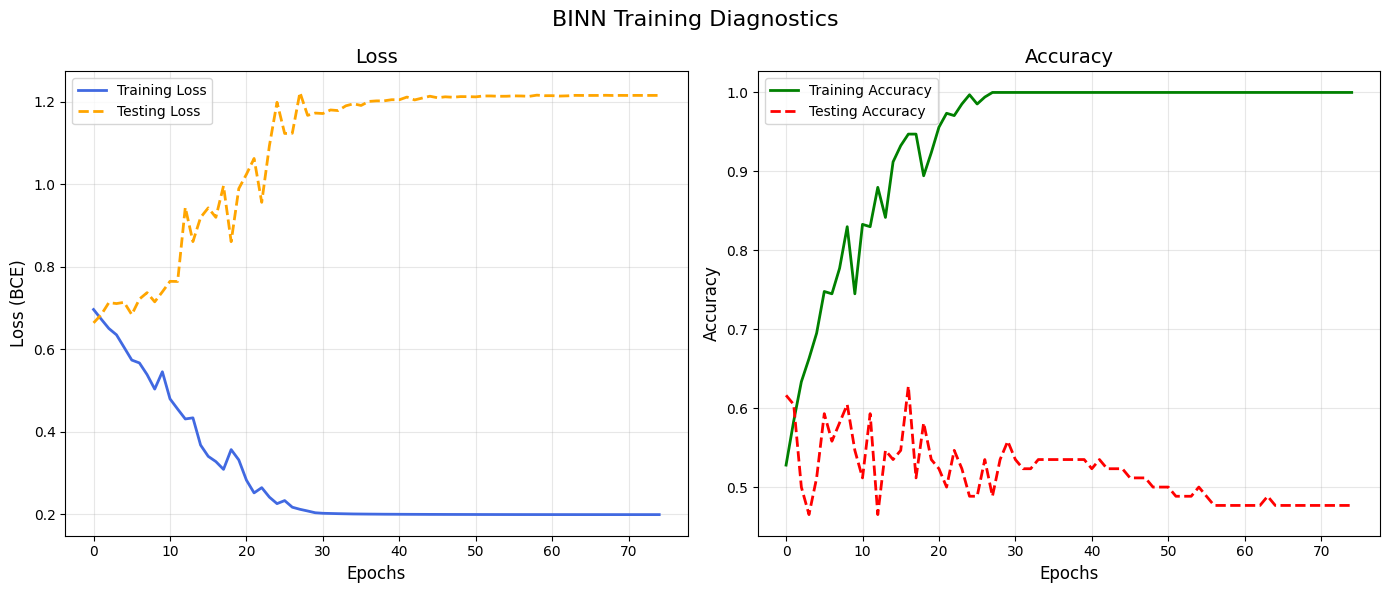

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Loss plot
axes[0].plot(history['train_loss'], label='Training Loss', color='royalblue', linewidth=2)
axes[0].plot(history['test_loss'], label='Testing Loss', color='orange', linestyle='--', linewidth=2)
axes[0].set_title('Loss', fontsize=14)
axes[0].set_xlabel('Epochs', fontsize=12)
axes[0].set_ylabel('Loss (BCE)', fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Training Accuracy', color='green', linewidth=2)
axes[1].plot(history['test_acc'], label='Testing Accuracy', color='red', linestyle='--', linewidth=2)
axes[1].set_title('Accuracy', fontsize=14)
axes[1].set_xlabel('Epochs', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('BINN Training Diagnostics', fontsize=16)
plt.tight_layout()
plt.show()

In [31]:
# CROSS VALIDATION
all_fold_scores = dh.run_cross_validation(adata_global, in_features, layers_list, tensor_masks, device, k=5, epochs=75)


--- Starting Fold 1/5 ---
Fold 1 Best Test AUC: 0.7018

--- Starting Fold 2/5 ---
Fold 2 Best Test AUC: 0.6535

--- Starting Fold 3/5 ---
Fold 3 Best Test AUC: 0.6920

--- Starting Fold 4/5 ---
Fold 4 Best Test AUC: 0.6568

--- Starting Fold 5/5 ---
Fold 5 Best Test AUC: 0.6909

Mean ROC-AUC: 0.6790 +/- 0.0199


In [32]:
# Hyperparameter tuning, takes a while 
#best_params = dh.hyperparameter_tuning_optuna(adata_global, in_features, layers_list, tensor_masks, device)